# SRA Multitask Learning & Routing Demo

このノートブックでは、SRAの最大の強みである**「マルチタスク学習における専門家（シナプス）の使い分け」**をデモします。

1つのモデルに対して `copy`（そのまま出力）と `reverse`（逆順に出力）という相反するタスクを同時に学習させます。
学習後、タスクに応じてルーターが**全く異なるシナプスの経路（ルーティング）を選択する様子**を可視化します。

## 1. 環境セットアップ

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. ライブラリとモデルの準備
複数のタスクをこなすため、少し多めの専門家（シナプス）を用意します。

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_experiment import make_multitask_batch, make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 専門家(シナプス)の数を8個にし、各トークンにつき2つの専門家を選ぶ設定
config = MoESRAConfig(
    vocab_size=30,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=8,  # マルチタスク用に少し増やす
    k=2,
    max_seq_len=32
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. マルチタスク学習の実行
`copy`タスクと`reverse`タスクが混ざったバッチを与えて同時に学習させます。

In [3]:
print("Multitask Training started...")
model.train()

epochs = 500
batch_size = 32
tasks = ["copy", "reverse"]

for epoch in range(epochs):
    # 複数のタスクが混ざったバッチを生成 (入力の先頭にタスクトークンが付与されます)
    x, y, batch_tasks = make_multitask_batch(tasks, batch_size, min_len=4, max_len=8, device=device)
    
    optimizer.zero_grad()
    y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1))
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | LB Loss: {lb_loss.item():.4f}")

print("Training finished!")

Multitask Training started...


Epoch 100/500 | Loss: 1.1548 | LB Loss: 4.9000


Epoch 200/500 | Loss: 0.7624 | LB Loss: 4.9000


Epoch 300/500 | Loss: 0.3560 | LB Loss: 4.9000


Epoch 400/500 | Loss: 0.3109 | LB Loss: 4.9000


Epoch 500/500 | Loss: 0.3581 | LB Loss: 4.9000
Training finished!


## 4. ルーティングの可視化とタスクごとの比較
1つのモデルに対して `copy` と `reverse` の入力をそれぞれ与え、ルーターがどのシナプスを選んだかを比較します。

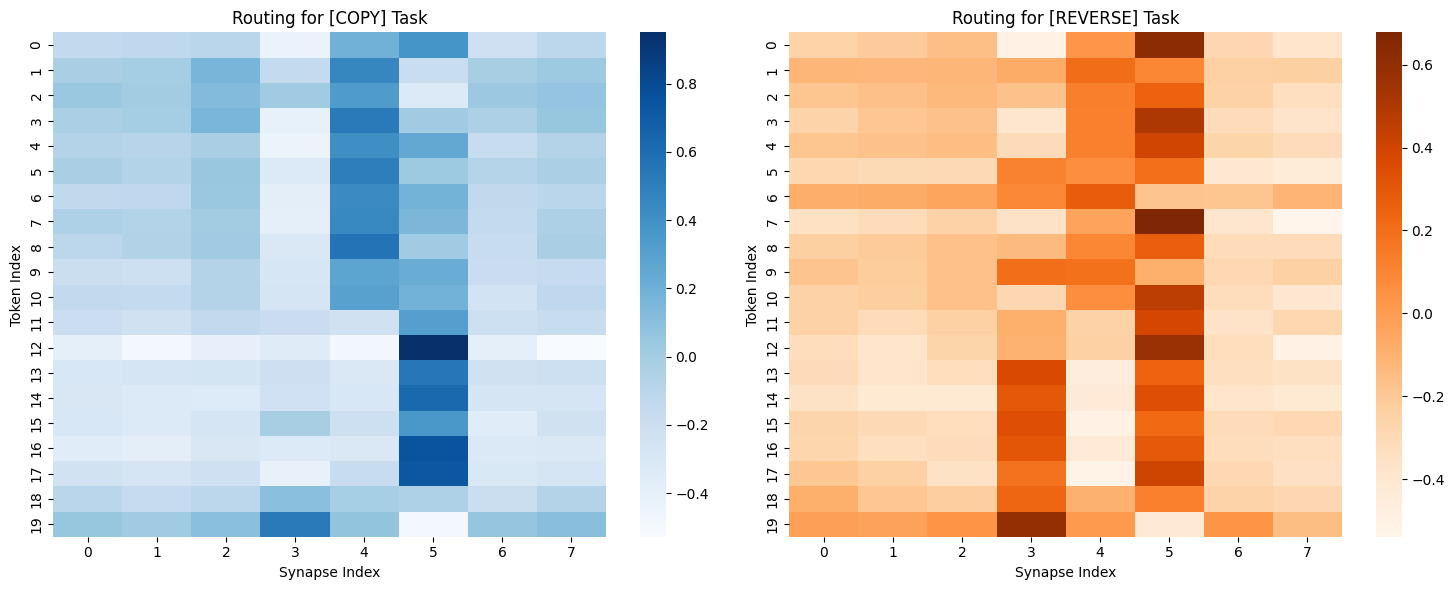

=== 💡 観察ポイント ===
左（青）のCopyタスクと、右（オレンジ）のReverseタスクで、
色が濃くなっているシナプス（X軸）の位置が異なっていることに注目してください。
これが、SRAが『タスクに応じて動的に専門家を切り替えている』証拠です！


In [4]:
def get_routing_weights_for_task(task):
    model.eval()
    # make_multitask_batchにタスクを1つだけ渡すと、そのタスク専用の入力が生成される
    x, y, _ = make_multitask_batch([task], batch_size=1, min_len=8, max_len=8, device=device)
    
    with torch.no_grad():
        y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
        _, routing_weights, _ = model(x, y_in)
        
    # [Layer 0][Sample 0] の重みを返す
    return routing_weights[0][0].cpu().numpy()

weights_copy = get_routing_weights_for_task("copy")
weights_reverse = get_routing_weights_for_task("reverse")

# 左右に並べてヒートマップを描画
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(weights_copy, cmap="Blues", ax=axes[0])
axes[0].set_title("Routing for [COPY] Task")
axes[0].set_xlabel("Synapse Index")
axes[0].set_ylabel("Token Index")

sns.heatmap(weights_reverse, cmap="Oranges", ax=axes[1])
axes[1].set_title("Routing for [REVERSE] Task")
axes[1].set_xlabel("Synapse Index")
axes[1].set_ylabel("Token Index")

plt.tight_layout()
plt.show()

print("=== 💡 観察ポイント ===")
print("左（青）のCopyタスクと、右（オレンジ）のReverseタスクで、")
print("色が濃くなっているシナプス（X軸）の位置が異なっていることに注目してください。")
print("これが、SRAが『タスクに応じて動的に専門家を切り替えている』証拠です！")